In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ecommerce_products.csv")

# Price clean
df["Price"] = (
    df["Price"]
    .str.replace("$", "", regex=False)
    .astype(float)
)

# Reviews clean
df["Reviews"] = (
    df["Reviews"]
    .astype(str) # Convert to string type first
    .str.replace("reviews", "", regex=False)
    .str.strip()
)

df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

print(df.head())

  Category                        Product Name   Price  \
0  Laptops          Asus VivoBook X441NA-GA190  295.99   
1  Laptops  Prestigio SmartBook 133S Dark Grey  299.00   
2  Laptops       Prestigio SmartBook 133S Gold  299.00   
3  Laptops                       Aspire E1-510  306.99   
4  Laptops                   Lenovo V110-15IAP  321.94   

                                         Description  Reviews  \
0  Asus VivoBook X441NA-GA190 Chocolate Black, 14...      NaN   
1  Prestigio SmartBook 133S Dark Grey, 13.3" FHD ...      NaN   
2  Prestigio SmartBook 133S Gold, 13.3" FHD IPS, ...      NaN   
3    15.6", Pentium N3520 2.16GHz, 4GB, 500GB, Linux      NaN   
4  Lenovo V110-15IAP, 15.6" HD, Celeron N3350 1.1...      NaN   

                                         Product URL  
0  https://webscraper.io/test-sites/e-commerce/al...  
1  https://webscraper.io/test-sites/e-commerce/al...  
2  https://webscraper.io/test-sites/e-commerce/al...  
3  https://webscraper.io/test-sites/e-co

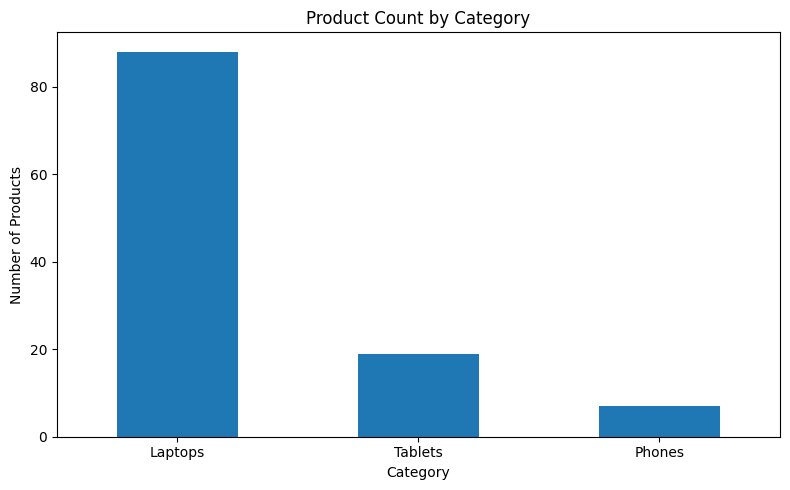

In [4]:
category_count = df["Category"].value_counts()

plt.figure(figsize=(8,5))

category_count.plot(kind="bar")

plt.title("Product Count by Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

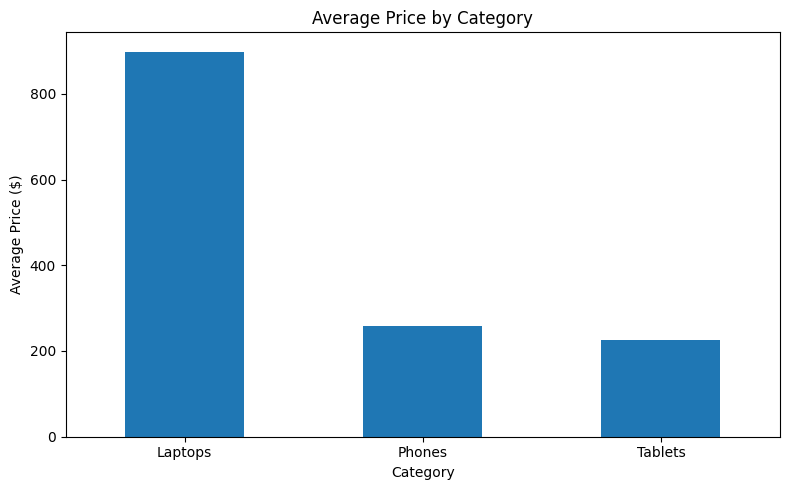

In [5]:
avg_price = df.groupby("Category")["Price"].mean()

plt.figure(figsize=(8,5))

avg_price.plot(kind="bar")

plt.title("Average Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price ($)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

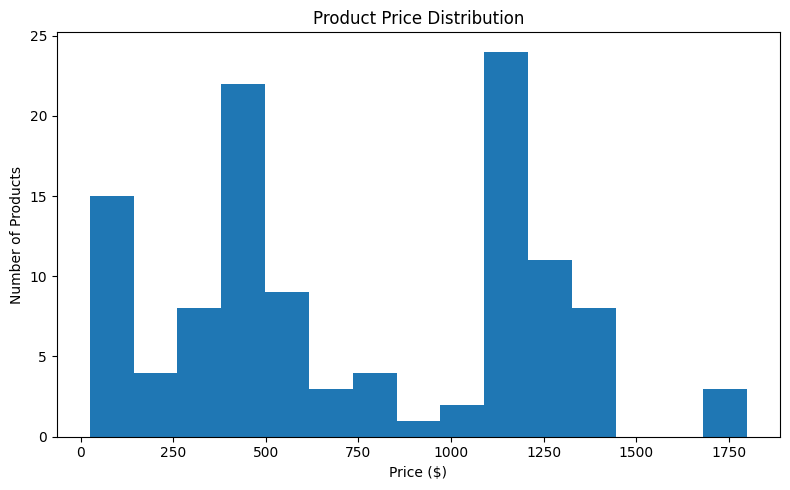

In [6]:
plt.figure(figsize=(8,5))

plt.hist(df["Price"], bins=15)

plt.title("Product Price Distribution")
plt.xlabel("Price ($)")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

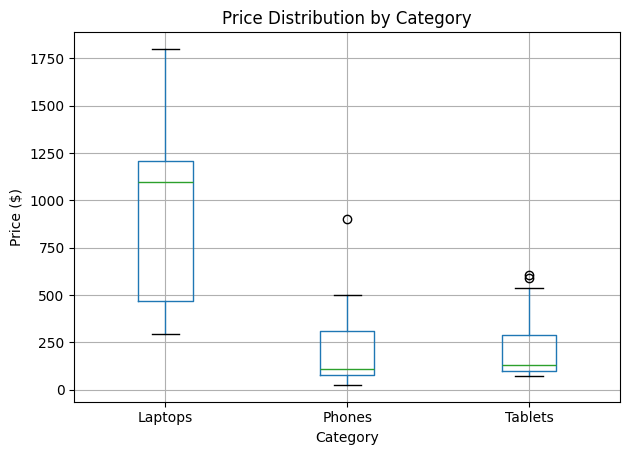

In [9]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="Price",
    by="Category"
)

plt.title("Price Distribution by Category")
plt.suptitle("")
plt.xlabel("Category")
plt.ylabel("Price ($)")

plt.tight_layout()
plt.show()

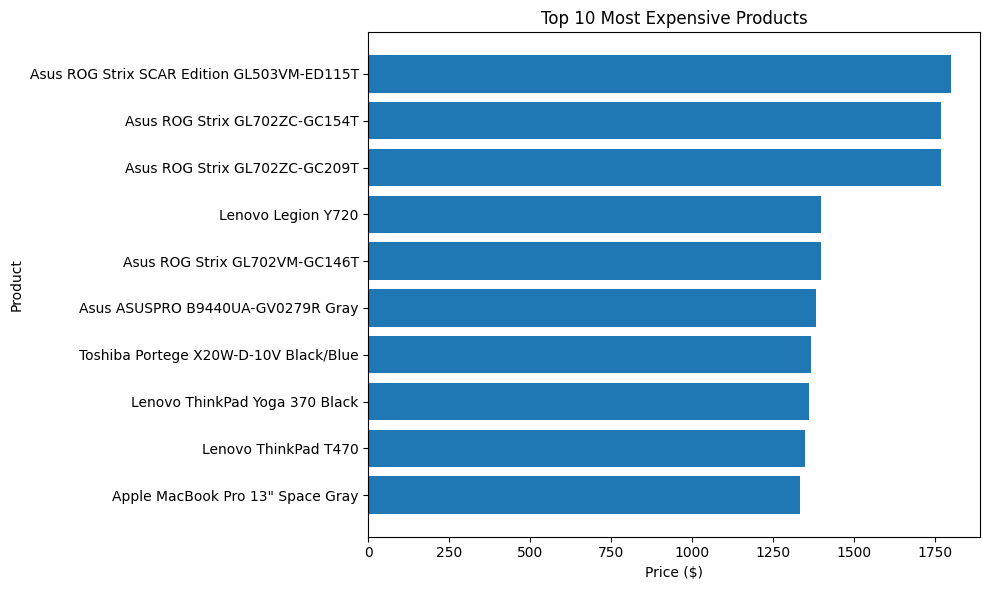

In [11]:
top_expensive = df.sort_values(
    "Price",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_expensive["Product Name"],
    top_expensive["Price"]
)

plt.title("Top 10 Most Expensive Products")
plt.xlabel("Price ($)")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

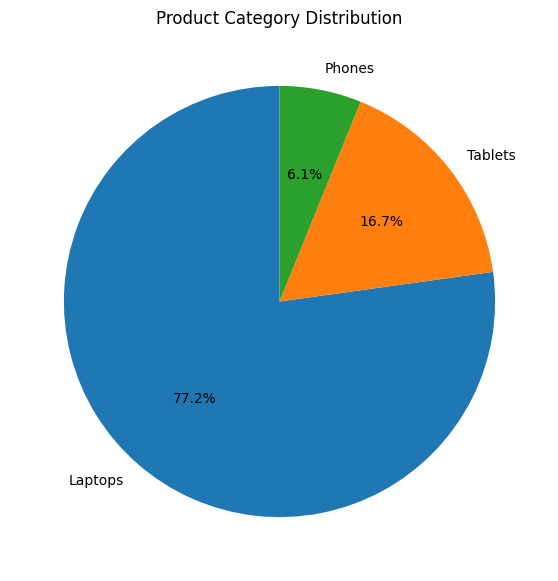

In [12]:
category_count = df["Category"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    category_count,
    labels=category_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Product Category Distribution")

plt.show()

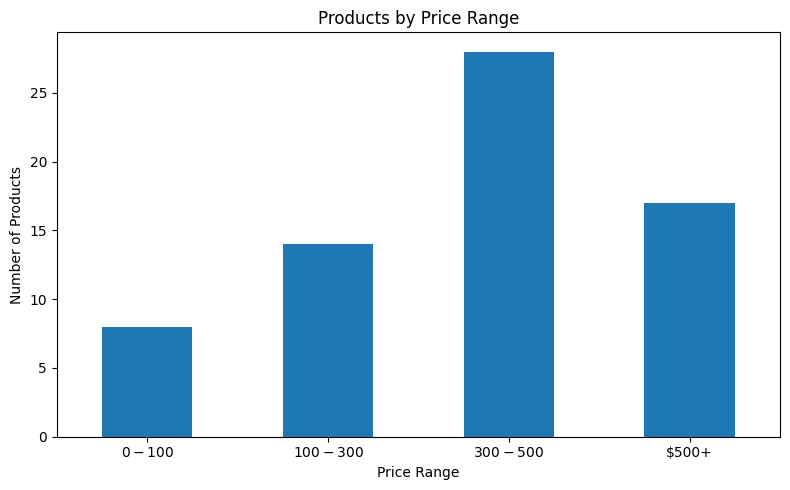

In [13]:
df["Price Range"] = pd.cut(
    df["Price"],
    bins=[0, 100, 300, 500, 1000],
    labels=["$0-$100", "$100-$300", "$300-$500", "$500+"]
)

price_range = df["Price Range"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

price_range.plot(kind="bar")

plt.title("Products by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Products")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

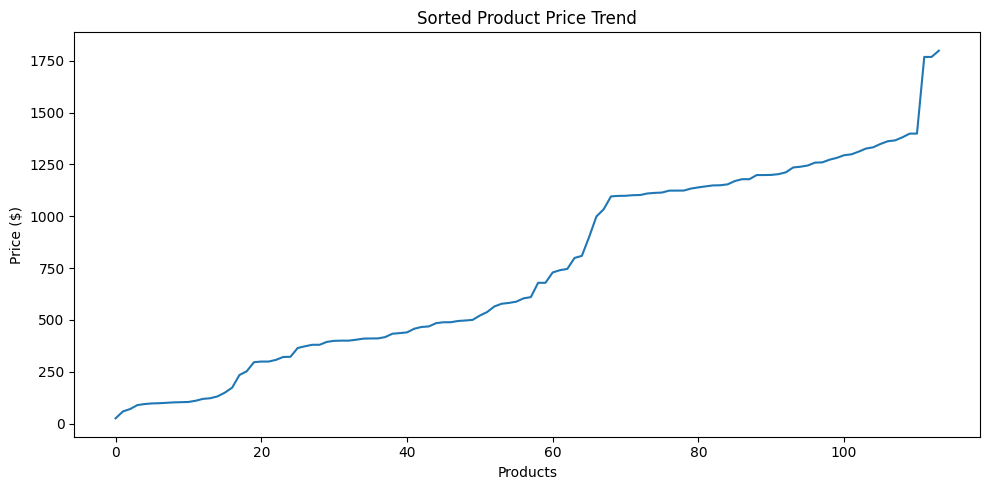

In [14]:
sorted_price = df.sort_values("Price")

plt.figure(figsize=(10, 5))

plt.plot(
    range(len(sorted_price)),
    sorted_price["Price"]
)

plt.title("Sorted Product Price Trend")
plt.xlabel("Products")
plt.ylabel("Price ($)")

plt.tight_layout()
plt.show()